In [ ]:
# -------------------------------
# SEGMENT 1 — Install & Download
# -------------------------------

!pip install kagglehub tensorflow matplotlib scikit-learn

import kagglehub
import os

# Download from Kaggle
path = kagglehub.dataset_download("jiayuanchengala/aid-scene-classification-datasets")
print("Dataset downloaded to:", path)

# Detect dataset root (AID has 30 folders)
def find_dataset_root(start_path):
    for root, dirs, files in os.walk(start_path):
        if len(dirs) >= 25:
            return root
    return start_path

data_dir = find_dataset_root(path)
print("AID dataset root:", data_dir)


100%|██████████| 2.45G/2.45G [00:21<00:00, 121MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/jiayuanchengala/aid-scene-classification-datasets/versions/1
AID dataset root: /root/.cache/kagglehub/datasets/jiayuanchengala/aid-scene-classification-datasets/versions/1/AID


In [ ]:
# -------------------------------
# SEGMENT 2 — Data Generators
# -------------------------------

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1/255.0,
    validation_split=0.25,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1/255.0,
    validation_split=0.25
)

train_gen = train_datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

val_gen = test_datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

num_classes = len(train_gen.class_indices)
class_names = list(train_gen.class_indices.keys())
print("Classes:", class_names)


Found 7507 images belonging to 30 classes.
Found 2493 images belonging to 30 classes.
Classes: ['Airport', 'BareLand', 'BaseballField', 'Beach', 'Bridge', 'Center', 'Church', 'Commercial', 'DenseResidential', 'Desert', 'Farmland', 'Forest', 'Industrial', 'Meadow', 'MediumResidential', 'Mountain', 'Park', 'Parking', 'Playground', 'Pond', 'Port', 'RailwayStation', 'Resort', 'River', 'School', 'SparseResidential', 'Square', 'Stadium', 'StorageTanks', 'Viaduct']


In [ ]:
# -------------------------------
# SEGMENT 3 — Build Model
# -------------------------------

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False   # freeze backbone

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
output = Dense(num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0008),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,296,414 (8.76 MB)

 Trainable params: 38,430 (150.12 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# -------------------------------
# SEGMENT 4 — Training
# -------------------------------

EPOCHS = 12

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 195s 734ms/step - accuracy: 0.3844 - loss: 2.3230 - val_accuracy: 0.7393 - val_loss: 0.8740
Epoch 2/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 136s 579ms/step - accuracy: 0.7739 - loss: 0.7520 - val_accuracy: 0.7822 - val_loss: 0.7063
Epoch 3/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 133s 568ms/step - accuracy: 0.8093 - loss: 0.6114 - val_accuracy: 0.8159 - val_loss: 0.6316
Epoch 4/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 136s 581ms/step - accuracy: 0.8350 - loss: 0.5140 - val_accuracy: 0.8075 - val_loss: 0.6319
Epoch 5/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 136s 580ms/step - accuracy: 0.8480 - loss: 0.4643 - val_accuracy: 0.8183 - val_loss: 0.5728
Epoch 6/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 136s 579ms/step - accuracy: 0.8646 - loss: 0.4265 - val_accuracy: 0.8323 - val_loss: 0.5454
Epoch 7/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 134s 572ms/step - accuracy: 0.8716 - loss: 0.3982 - val_accuracy: 0.8219 - val_loss: 0.5572
Epoch 8/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 133s 567ms/step - accuracy: 0.8824 -

In [ ]:
# -------------------------------
# SEGMENT 5 — Evaluate
# -------------------------------

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

val_gen.reset()
preds = model.predict(val_gen)

y_pred = np.argmax(preds, axis=1)
y_true = val_gen.classes

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


78/78 ━━━━━━━━━━━━━━━━━━━━ 24s 245ms/step

Classification Report:

                   precision    recall  f1-score   support

          Airport       0.52      0.94      0.67        90
         BareLand       0.95      0.70      0.81        77
    BaseballField       0.91      0.95      0.93        55
            Beach       0.96      0.81      0.88       100
           Bridge       0.89      0.83      0.86        90
           Center       0.91      0.65      0.76        65
           Church       0.64      0.82      0.72        60
       Commercial       0.70      0.82      0.76        87
 DenseResidential       0.89      0.85      0.87       102
           Desert       0.94      0.96      0.95        75
         Farmland       0.86      0.96      0.91        92
           Forest       0.90      0.89      0.89        62
       Industrial       0.82      0.71      0.76        97
           Meadow       0.97      0.80      0.88        70
MediumResidential       0.88      0.85      0.8

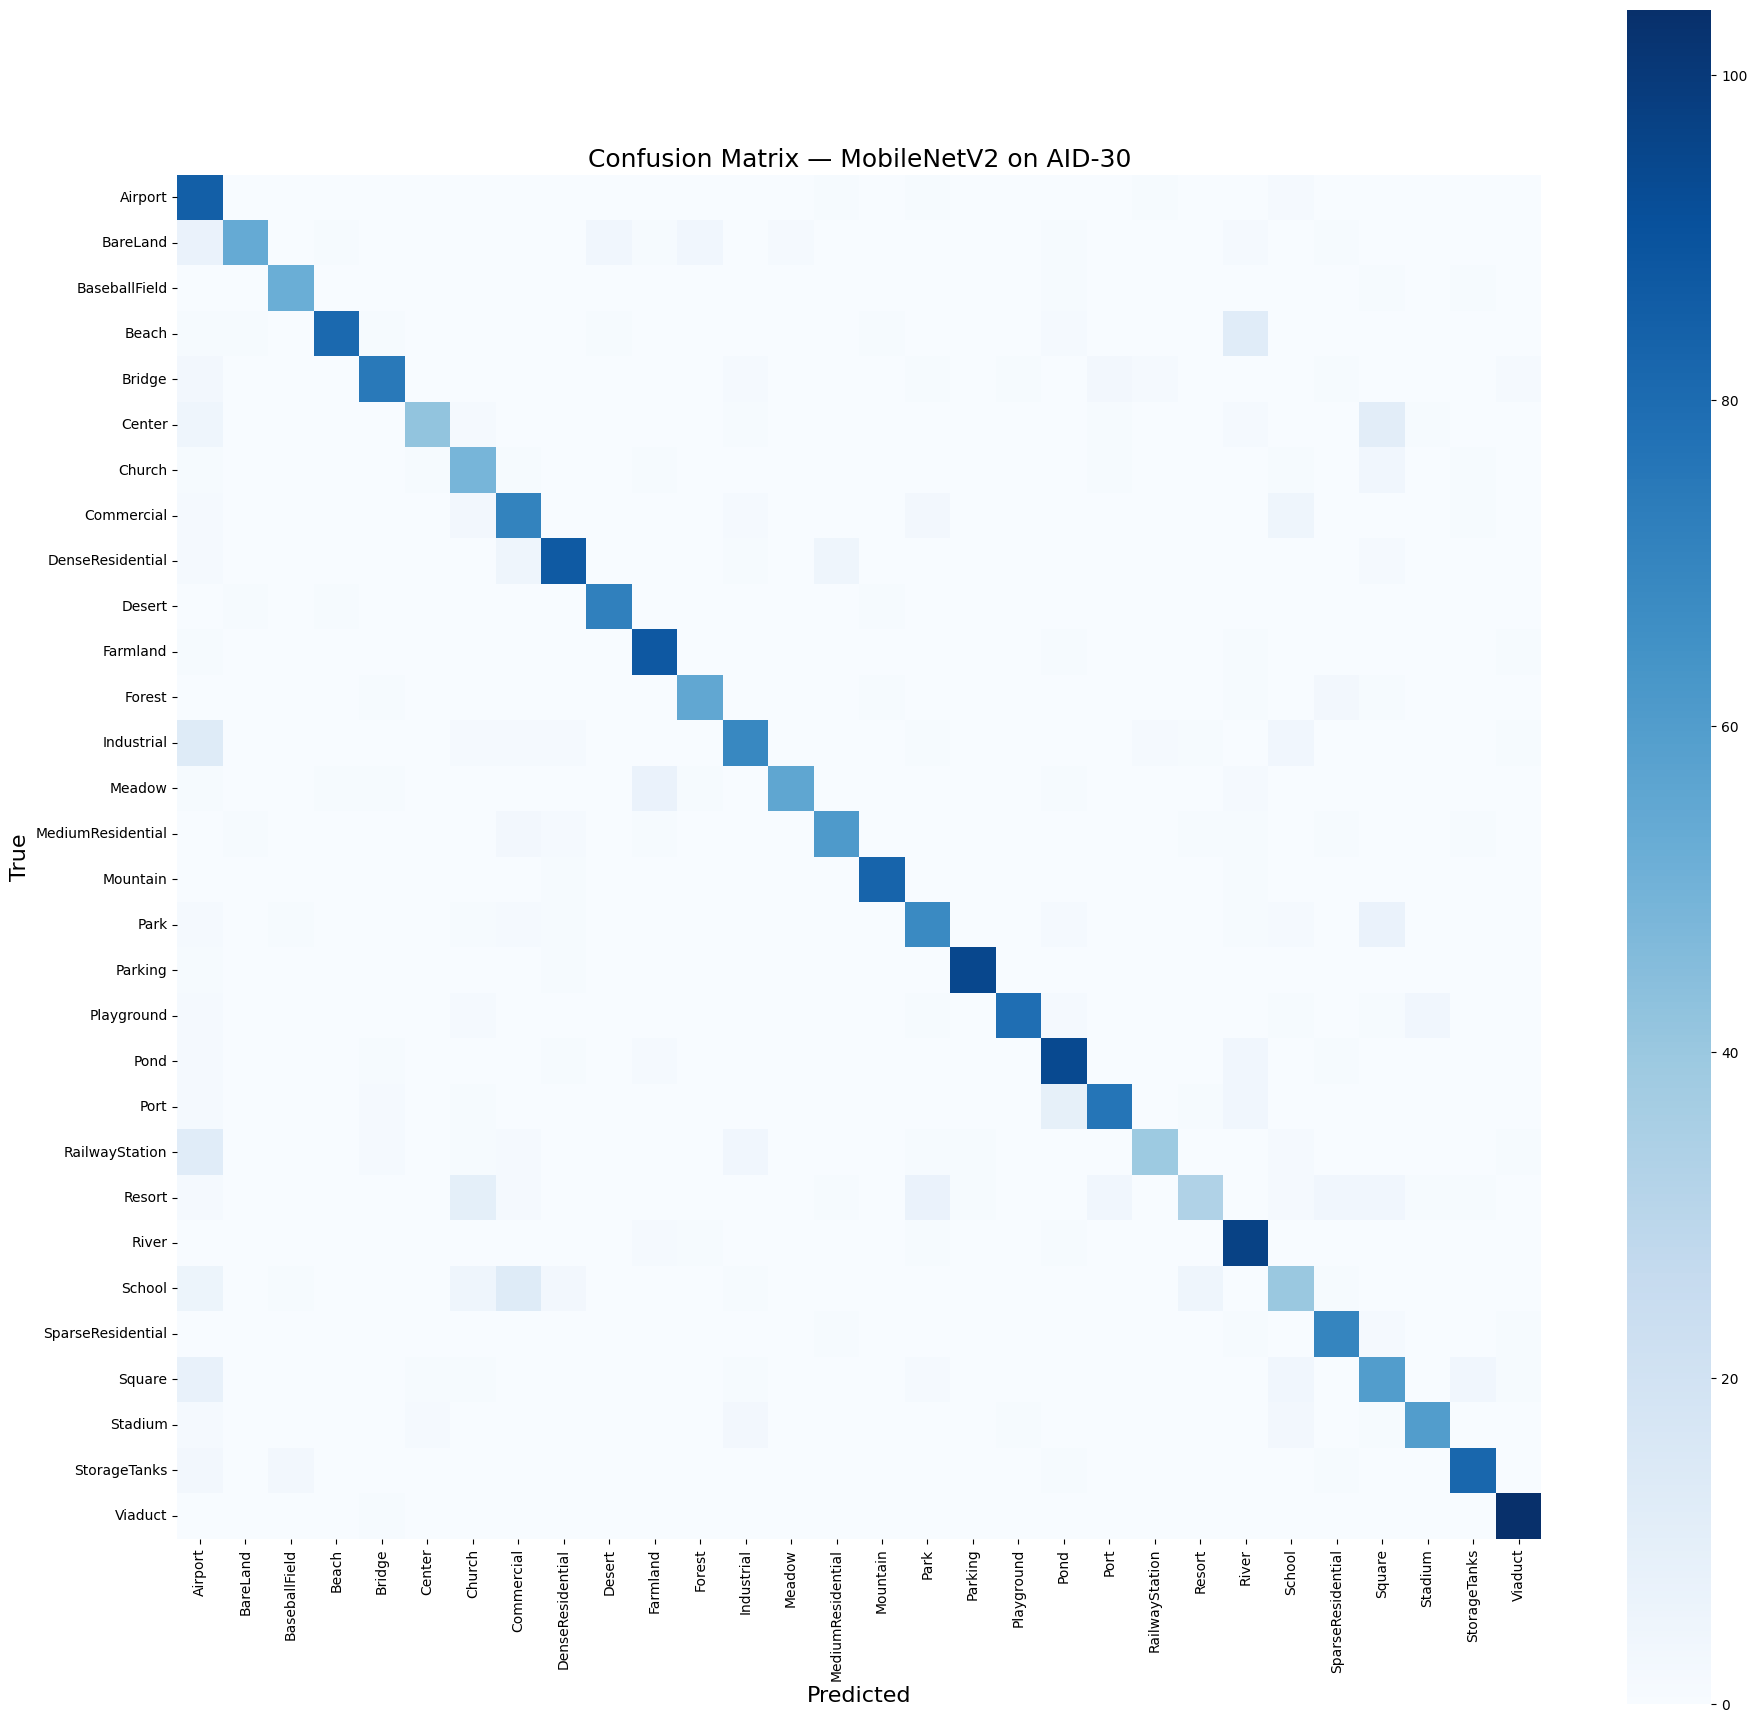

In [ ]:
# -------------------------------
# SEGMENT 6 — Confusion Matrix Plot
# -------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(22, 22))
sns.heatmap(cm, annot=False, cmap="Blues", square=True,
            xticklabels=class_names, yticklabels=class_names)

plt.title("Confusion Matrix — MobileNetV2 on AID-30", fontsize=18)
plt.xlabel("Predicted", fontsize=16)
plt.ylabel("True", fontsize=16)
plt.show()


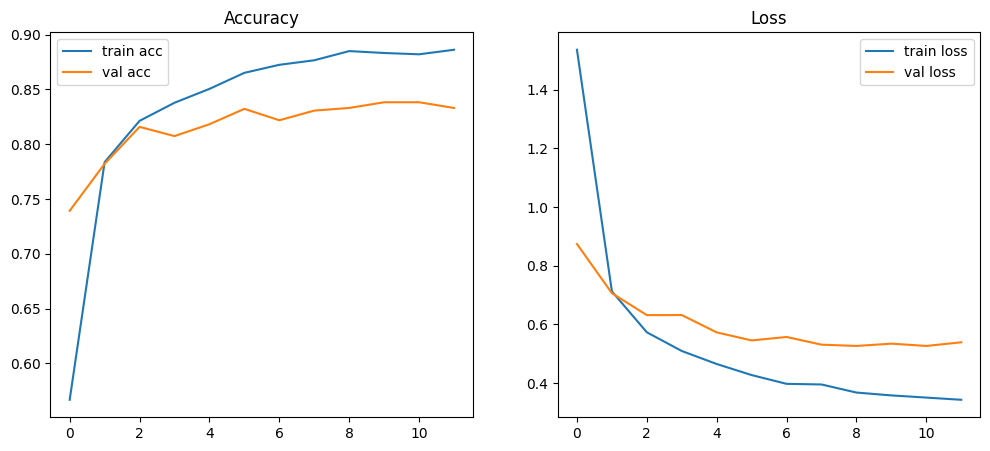

In [ ]:
# -------------------------------
# SEGMENT 7 — Plot Accuracy & Loss
# -------------------------------

plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.title('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Loss')
plt.legend()

plt.show()
